In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import sys
import warnings
warnings.filterwarnings('ignore') 
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from scipy.optimize import minimize

from datasets import circle, plot_circle, diamond, plot_diamond, wavy_lines, plot_wavy
import single_qubit
from single_qubit import *
import importlib
importlib.reload(single_qubit)
import plotting
from plotting import *
importlib.reload(plotting)

<module 'plotting' from '/home/ubuntu/jupyter-env/data-reuploading-classifier/plotting.py'>

# Circle

In [4]:
all_losses_circle = {}
all_train_accuracies_circle = {}
all_test_accuracies_circle = {}

In [24]:
data, (centers, radii) = circle(samples=4200, random_seed=42)
x = np.array([i[0] for i in data])
y = np.array([i[1] for i in data])

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.95,
    random_state=42,
    stratify=y) #stratify allows to have a balance amount of labels in each split


print("Train/Test datasets")
print(f"Train: {len(x_train)} samples")
print(f"Test: {len(x_test)} samples")

Train/Test datasets
Train: 210 samples
Test: 3990 samples


### 1 layer

In [41]:
n_layers = 1
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers]= loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)


[[0.53533039 4.08465134 4.10704477]] [[0.95622117 0.00302087 0.24793245]] [0.92779148 0.93213392]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 105.755313
Iteration 2, cost: 105.302833
Iteration 3, cost: 71.454935
Iteration 4, cost: 71.391691
Iteration 5, cost: 67.504020
Iteration 6, cost: 66.131781
Iteration 7, cost: 66.037225
Iteration 8, cost: 66.000906
Iteration 9, cost: 65.986673
Iteration 10, cost: 65.986628
Iteration 11, cost: 65.986627
Iteration 12, cost: 65.986627
Iteration 13, cost: 65.986627
[[2.8745616  4.08464828 4.10704202]] [[-3.24917625  0.22082721  0.24793245]]
Optimization success: True
Final cost: 65.986627
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [42]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7296


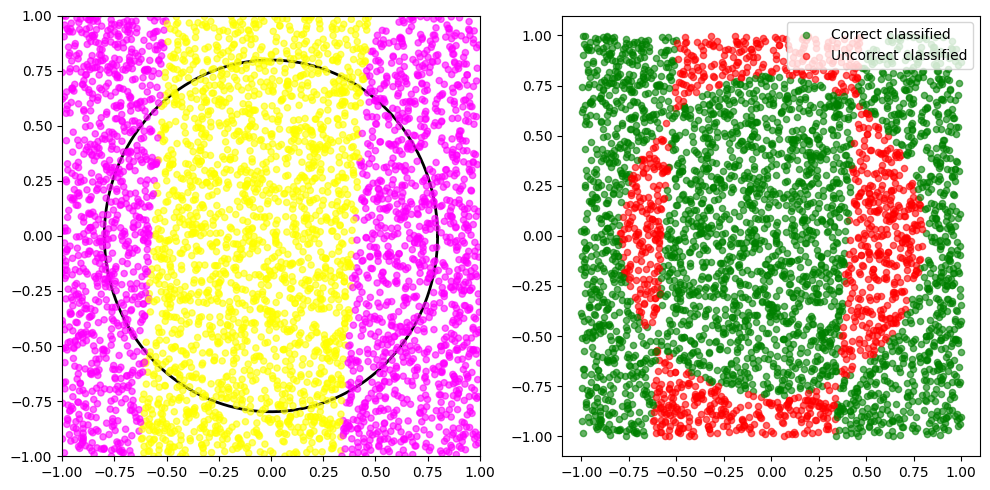

In [43]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 2 layers

In [44]:
n_layers = 2
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[4.527578   4.81143285 0.57480438]
 [3.22877709 1.45507885 1.13862655]] [[0.8103033  0.13503814 0.46865164]
 [0.93857824 0.18583206 0.97799342]] [0.99428799 0.55561715]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 80.826590
Iteration 2, cost: 72.368698
Iteration 3, cost: 69.355606
Iteration 4, cost: 67.508640
Iteration 5, cost: 67.370172
Iteration 6, cost: 67.366946
Iteration 7, cost: 67.366850
Iteration 8, cost: 67.366844
Iteration 9, cost: 67.366844
Iteration 10, cost: 67.366844
Iteration 11, cost: 67.366844
Iteration 12, cost: 67.366844
[[4.84996638 5.11557333 0.57480398]
 [4.84996654 1.45507871 1.44276724]] [[ 1.28071052 -0.13363737  0.46865164]
 [ 1.28071061 -0.13363724  0.97799342]]
Optimization success: True
Final cost: 67.366844
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [45]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.7108


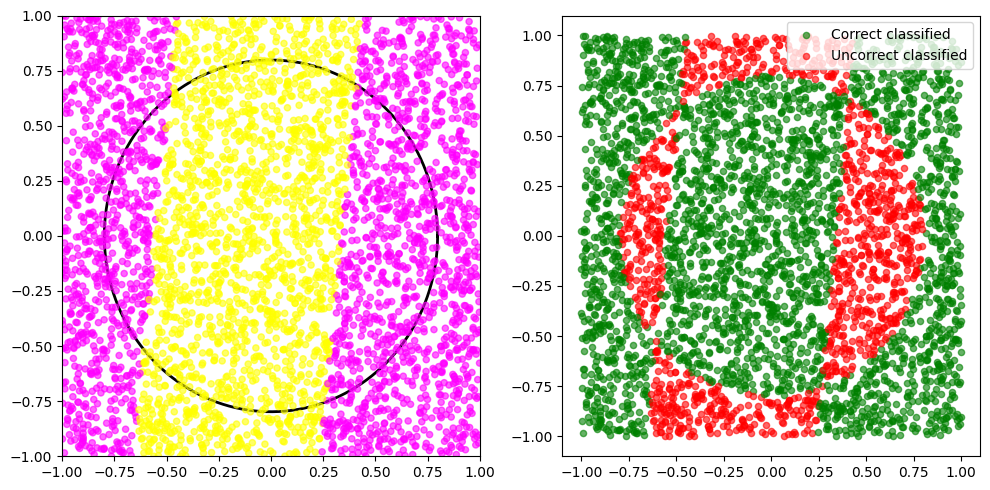

In [40]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 4 layers

In [37]:
#16 min
n_layers = 4
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 200,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[2.82803198 0.13907486 4.02570107]
 [2.60077413 1.69682739 1.29959589]
 [4.10934819 2.61516873 1.12883261]
 [4.32980006 3.55045387 5.39519564]] [[0.1174759  0.7856666  0.67351679]
 [0.11501094 0.69482073 0.44154729]
 [0.94498479 0.14161135 0.64283339]
 [0.38198005 0.95681467 0.3299749 ]] [0.96218591 0.90148585]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 90.504968
Iteration 2, cost: 79.726898
Iteration 3, cost: 66.994274
Iteration 4, cost: 61.781238
Iteration 5, cost: 59.350841
Iteration 6, cost: 57.460426
Iteration 7, cost: 56.133043
Iteration 8, cost: 54.778688
Iteration 9, cost: 54.065218
Iteration 10, cost: 53.849941


KeyboardInterrupt: 

In [14]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.8907


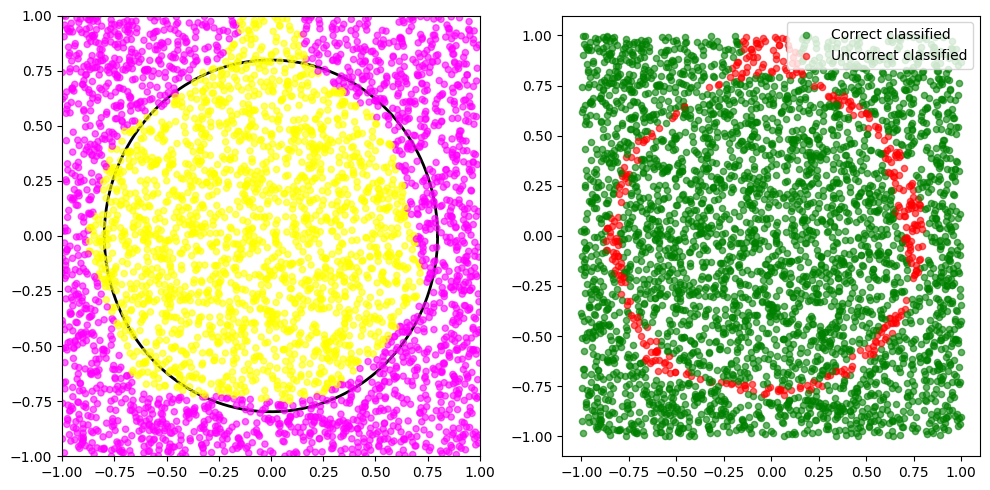

In [23]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 8 layers

In [16]:
# 45 min
n_layers = 8
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 500,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

[[5.48681894 4.42908727 0.53533039]
 [4.08465134 4.10704477 6.00811483]
 [0.01898069 1.55780553 5.82948579]
 [5.85677012 4.527578   4.81143285]
 [0.57480438 3.22877709 1.45507885]
 [1.13862655 5.09128578 0.84846964]
 [2.94462508 5.897261   1.16761724]
 [6.14491391 6.24729566 3.49104554]] [[1.70142740e-01 3.16104888e-01 4.24492833e-01]
 [3.09324224e-01 2.80635580e-01 9.72229709e-01]
 [1.53364827e-01 7.33327909e-01 4.10289439e-04]
 [5.96182669e-01 9.15943004e-01 2.87934094e-01]
 [1.85525975e-01 6.51679795e-01 7.12601407e-01]
 [6.88030519e-01 3.19316880e-01 2.52202402e-01]
 [9.55918800e-01 9.23299508e-01 4.57316610e-01]
 [8.46193866e-01 4.52323478e-01 4.24389018e-01]] [0.15676295 0.42640606]
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Iteration 1, cost: 88.055538
Iteration 2, cost: 83.455447
Iteration 3, cost: 76.682572
Iteration 4, cost: 74.019189
Iteration 5, cost: 66.321510
Iteration 6, cost: 60.403609
Iteration 7, cost: 54.913720
Iteration 8, cost: 52.262091
Iteration 9, cost: 50.716666
Iterat

In [18]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

Test accuracy: 0.9085


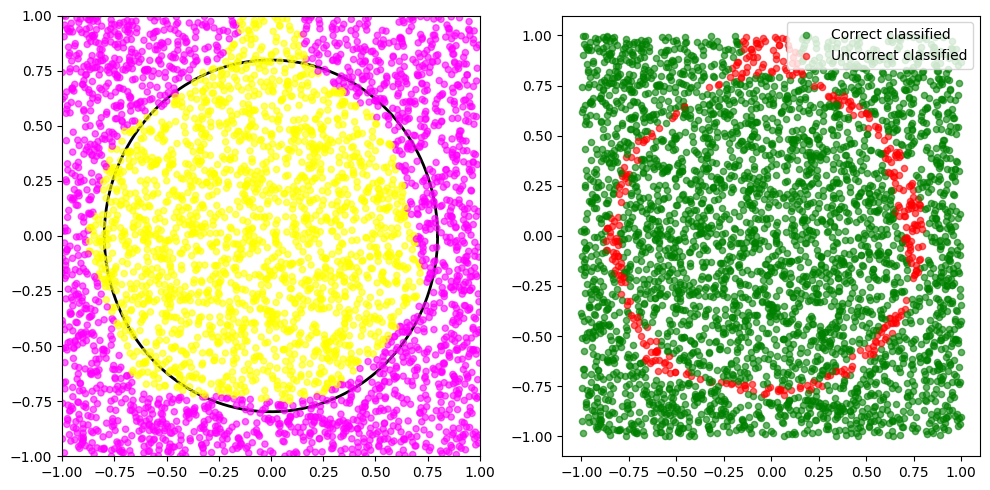

In [21]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 12 layers

In [ ]:
n_layers = 12
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history = []
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 250,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)

theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

In [ ]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

In [ ]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)

### 16 layers

In [ ]:
n_layers = 16
n_classes = 2

theta, w, alpha = single_qubit_params(n_layers,n_classes)
print(theta, w, alpha)

reprs = representatives(n_classes,1)
print(reprs)

params= pack_params(theta, w, alpha) 

iteration = [0]
loss_history=[]
def callback(params):

    iteration[0] += 1
    cost = single_cost_function(params, x_train, y_train, n_layers, n_classes, reprs)
    loss_history.append(cost)
    print(f"Iteration {iteration[0]}, cost: {cost:.6f}")

result = minimize(
    fun= single_cost_function,
    x0=params,
    args=(x_train, y_train, n_layers, n_classes, reprs),
    method='L-BFGS-B',
    callback=callback,
    options={
        'maxiter': 200,
        'ftol': 1e-12,
        'gtol': 1e-8,      
    }
)


theta_opt, w_opt, _ = single_unpack_params(result.x, n_layers, n_classes)
print(theta_opt, w_opt)

print(f"Optimization success: {result.success}")
print(f"Final cost: {result.fun:.6f}")
print(f"Message: {result.message}")

all_losses_circle[n_layers] = loss_history
train_preds = single_qubit_predict(x_train, n_layers, n_classes, theta_opt, w_opt, reprs)
all_train_accuracies_circle[n_layers] = np.mean(train_preds == y_train)

In [ ]:
preds = single_qubit_predict(x_test, n_layers, n_classes, 
                theta_opt, w_opt, reprs)
accuracy = np.mean(preds == y_test)
print(f"Test accuracy: {accuracy:.4f}")
all_test_accuracies_circle[n_layers] = accuracy

In [ ]:
x_test = np.array(x_test)
y_test = np.array(y_test)
preds = np.array(preds)

decision_plot_circle(x_test, y_test, preds)